In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import multiprocessing
import os
from skimage.filters.rank import entropy
from skimage.morphology import disk

from pathlib import Path
import glob 
import skimage
from skimage.io import imread
from skimage.filters import threshold_multiotsu

Here we compute the signal to noise ratio as a metric of image quality. To define background and signal, we use otsu thresholding. 
However, the idea of otsu thresholding works if signal was bimodal, which it isn't in our data (see example below)

In [170]:
path0 = '../../'
base_dir = Path(path0,'Img_Denoised','contrast_adj')
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension
biosamples_path = path0+'IMC_preprocessing/processed_files/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)
biosamples

# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*')
tb = pd.DataFrame(glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True),columns = ['filepath'])
acq_mark = pd.DataFrame(list(tb.filepath.str.split('/').str[-2:]),columns = ['acquisition','marker'])
acq_mark['marker'] = acq_mark.marker.str.rstrip('.tiff')
tb = pd.concat([tb,acq_mark],axis=1)
tb = tb[tb.marker!='Carboplatin']

In [171]:
tb

,filepath,acquisition,marker
0,../../Img_Denoised/contrast_adj/Leap081_8/B7-H...,Leap081_8,B7-H4
1,../../Img_Denoised/contrast_adj/Leap081_8/Alph...,Leap081_8,Alpha-SMA
2,../../Img_Denoised/contrast_adj/Leap081_8/CD10...,Leap081_8,CD107a
3,../../Img_Denoised/contrast_adj/Leap081_8/CD8a...,Leap081_8,CD8a
4,../../Img_Denoised/contrast_adj/Leap081_8/CD14...,Leap081_8,CD14
...,...,...,...
25721,../../Img_Denoised/contrast_adj/Leap017_15/Ki-...,Leap017_15,Ki-67
25722,../../Img_Denoised/contrast_adj/Leap017_15/CD1...,Leap017_15,CD163
25723,../../Img_Denoised/contrast_adj/Leap017_15/CD1...,Leap017_15,CD16
25724,../../Img_Denoised/contrast_adj/Leap017_15/DNA...,Leap017_15,DNA2


In [42]:
next(tb.iterrows())

(0,
 filepath       ../../Img_Denoised/processed/Leap081_8/B7-H4.tiff
 acquisition                                            Leap081_8
 marker                                                     B7-H4
 Name: 0, dtype: object)

In [172]:
def quality_control(filename):
    image = imread(filename)
    thresholds = threshold_multiotsu(image,classes=2)
    # Using the threshold values, we generate two regions, background and foregroung
    is_fg = np.digitize(image, bins=thresholds).astype(bool)
    s_i = image[is_fg].mean() #mean signal intensity
    snr = s_i/(image[~is_fg].mean())#ratio:  foregroud/backgroud
    image = skimage.exposure.rescale_intensity(image,in_range=(0, 1))
    e = entropy(image,disk(5)).mean()
    return s_i,snr,e
with multiprocessing.Pool() as pool:
     data = pool.map(quality_control, tb.filepath)
tb[['signal_intensity','snr','entropy']] = data    

/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return list(map(*args))
/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return list(map(*args))
/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return list(map(*args))
/home/giuseppe/anaconda3/lib/python3.9/multiprocessing/pool.py:48: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. 

In [173]:
tb.to_csv('data/quality_metrics.csv',index=False)

In [ ]:
tb = pd.read_csv('data/quality_metrics')

<Axes: xlabel='marker', ylabel='entropy'>

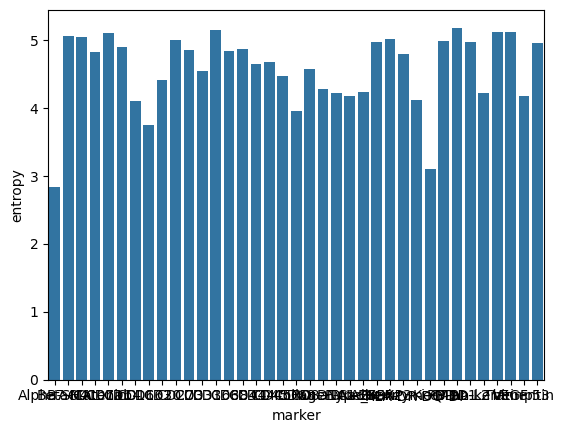

In [214]:
q_metrics = tb.groupby('marker')[['signal_intensity','snr','entropy']].median()
sns.barplot(  q_metrics['entropy'])


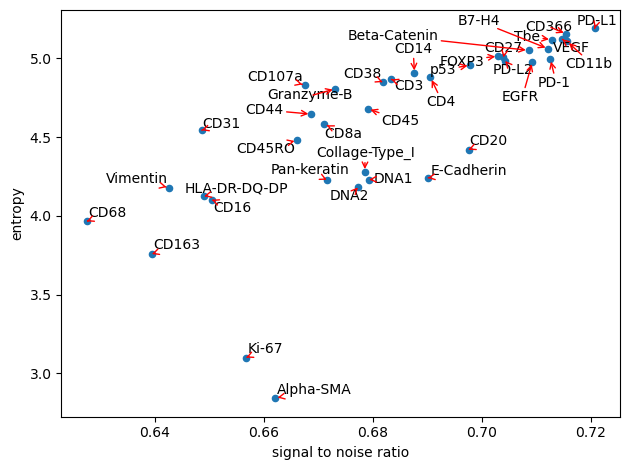

In [197]:
from adjustText import adjust_text
q_metrics = tb.groupby('marker')[['signal_intensity','snr','entropy']].median()
#q_metrics.drop('Carboplatin',axis = 0,inplace=True)
#for carboplatin, we take only the resection images
tb['LEAP_ID'] = tb.acquisition.str.split('_',n = 1).str[0].str.upper()
a = tb.merge(biosamples,left_on='LEAP_ID',right_on='LEAP_ID')
cond=(a['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION')*(a['marker']=='Carboplatin')
#q_metrics = pd.concat((q_metrics,tb[cond].groupby('marker')[q_metrics.columns].median())).rename(index={'Carboplatin': 'Carboplatin*'})

#np.log2(q_metrics).plot(x = 'signal_intensity',y='snr',kind='scatter',c = q_metrics.entropy,colormap='jet' )
q_metrics.plot(x = 'signal_intensity',y='entropy',kind='scatter' )
plt.xlabel('entropy')
plt.xlabel('signal to noise ratio')
a = [plt.annotate(text,(b,c)) for text,(b,c) in q_metrics[['signal_intensity','entropy']].iterrows()]
adjust_text(a, arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
#plt.savefig('qc_noise.png')

<Axes: xlabel='signal_intensity', ylabel='entropy'>

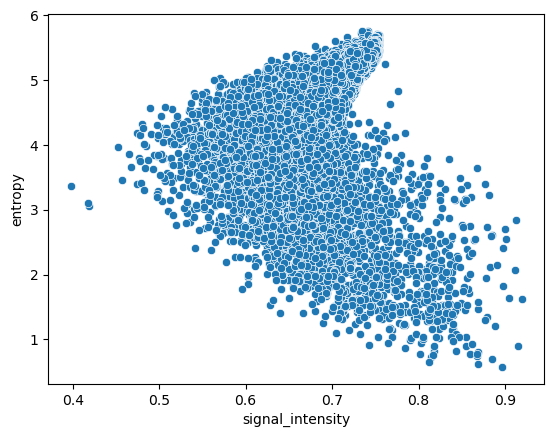

In [188]:
sns.scatterplot(tb, x = 'signal_intensity',y='entropy' )

In [180]:
a = tb.sort_values('entropy')
#tb.acquisition
#tb.sort_values('signal_intensity')
#cond = (tb.entropy>1)*(tb.signal_intensity<0.8)
tb.sort_values('entropy')

,filepath,acquisition,marker,signal_intensity,snr,entropy,LEAP_ID
16873,../../Img_Denoised/contrast_adj/Leap015_2/Alph...,Leap015_2,Alpha-SMA,0.896430,96.504707,0.577757,LEAP015
17155,../../Img_Denoised/contrast_adj/Leap056_4/Pan-...,Leap056_4,Pan-keratin,0.868730,63.595200,0.624243,LEAP056
21243,../../Img_Denoised/contrast_adj/Leap005_2_4/Al...,Leap005_2_4,Alpha-SMA,0.812090,54.340809,0.651171,LEAP005
23577,../../Img_Denoised/contrast_adj/Leap056_8/Pan-...,Leap056_8,Pan-keratin,0.885266,58.344788,0.701294,LEAP056
11124,../../Img_Denoised/contrast_adj/Leap084_b_21/C...,Leap084_b_21,CD20,0.814015,51.953598,0.731162,LEAP084
...,...,...,...,...,...,...,...
749,../../Img_Denoised/contrast_adj/Leap008_1/Beta...,Leap008_1,Beta-Catenin,0.752007,3.056767,5.718015,LEAP008
8337,../../Img_Denoised/contrast_adj/Leap073_2/CD11...,Leap073_2,CD11b,0.733588,2.762395,5.728240,LEAP073
8338,../../Img_Denoised/contrast_adj/Leap073_2/VEGF...,Leap073_2,VEGF,0.739802,2.787863,5.736762,LEAP073
8322,../../Img_Denoised/contrast_adj/Leap073_2/B7-H...,Leap073_2,B7-H4,0.741123,2.793924,5.750957,LEAP073


show an example where this is done for one image

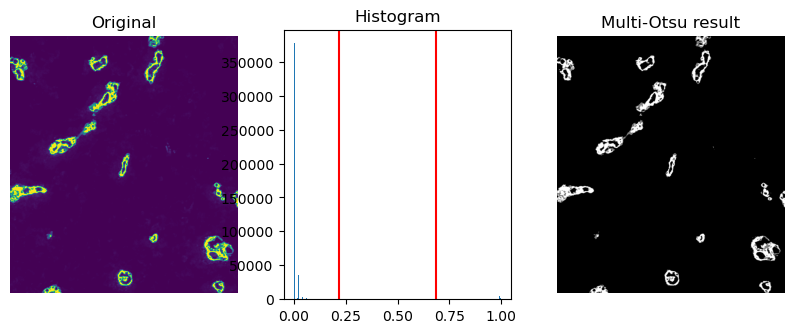

../../Img_Denoised/contrast_adj/Leap041_4/Alpha-SMA.tiff


In [195]:
filename = tb.sort_values('entropy')['filepath'].iloc[10]
image = imread(filename)
from skimage.filters import threshold_multiotsu
thresholds = threshold_multiotsu(image)
# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='gray')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()
print(filename)

PosixPath('Leap055_14/CD20.tiff')

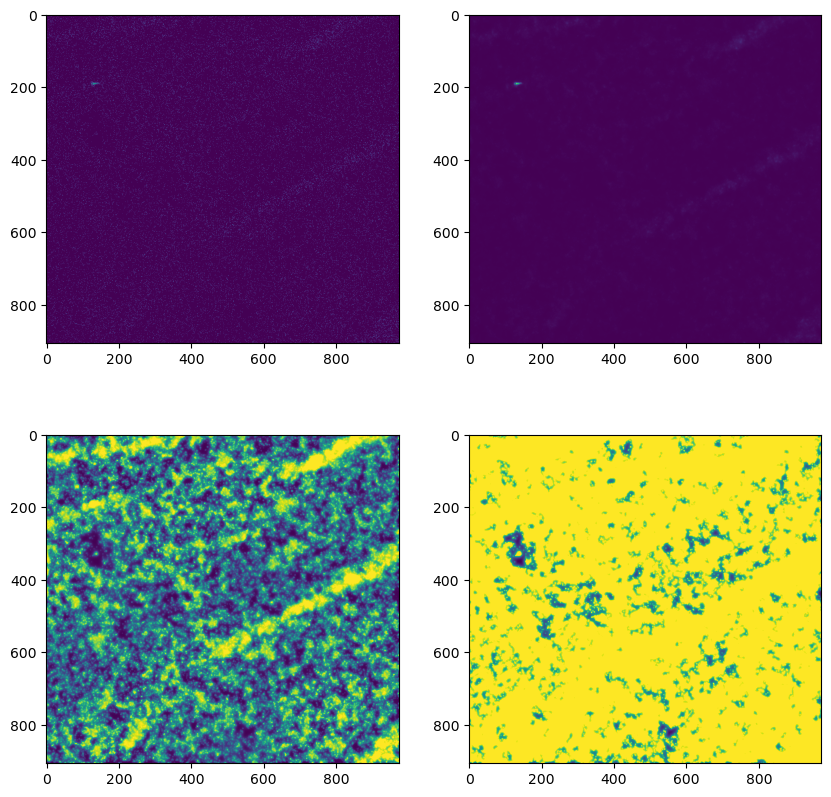

In [169]:
p = Path(filename)
ending= Path(*p.parts[-2:])
f,axs = plt.subplots(nrows = 2,ncols = 2,figsize = (10,10))

axs[0,0].imshow(np.log1p(imread(Path('../../split_channels_nohpf/',ending))))
img = imread(Path('../../Img_Denoised/non_preprocessed/',ending))
axs[0,1].imshow(np.log1p(img))
#axs[1,0].imshow(imgs[i])
img = imread(Path('../../Img_Denoised/non_preprocessed/',ending))
p2, p98 = np.percentile(img, (0, 98))
img = skimage.exposure.rescale_intensity(img,in_range=(p2,p98), out_range = (0,.999))#added out_range to something <1 because otherwise rounding >1
img = skimage.exposure.equalize_adapthist(img,clip_limit=0.01)
axs[1,0].imshow(img)
axs[1,1].imshow(imread(Path('../../Img_Denoised/processed/',ending)))
ending


(0.020404119044542313, 0.06542459577322006)

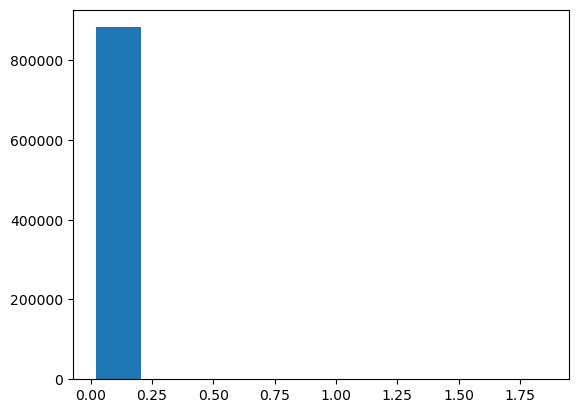

In [156]:
img = np.log1p(imread(Path('../../Img_Denoised/non_preprocessed/',ending)))
plt.hist(img.reshape(-1))
p2,p98

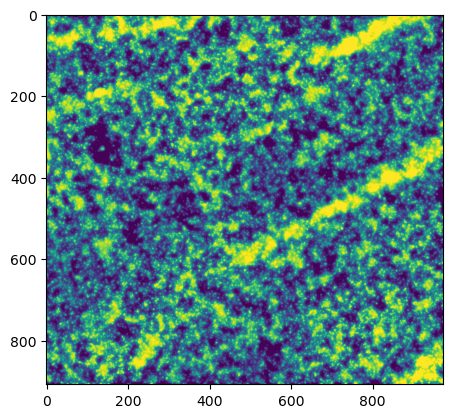

In [162]:
def load_and_enhance(name):
    img = skimage.io.imread(name)
    p2, p98 = np.percentile(img, (2, 98))
    img = skimage.exposure.rescale_intensity(img,in_range=(p2,p98), out_range = (0,.999))#added out_range to something <1 because otherwise rounding >1
    img = skimage.exposure.equalize_adapthist(img)
    return img
plt.imshow(load_and_enhance(Path('../../Img_Denoised/non_preprocessed/',ending)))

In [117]:
image.max()

1.0

<Axes: xlabel='entropy', ylabel='signal_intensity'>

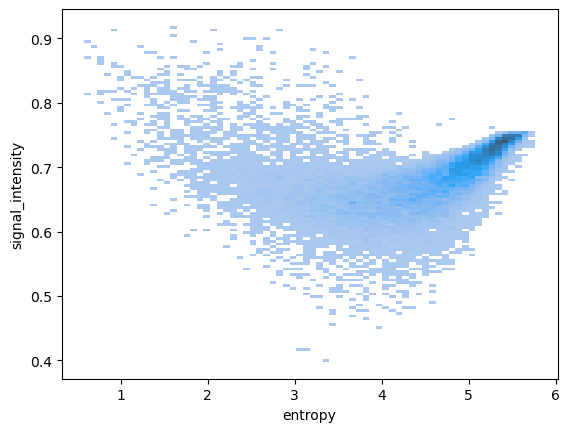

In [184]:
#sns.histplot(image2.reshape(-1))
sns.histplot(tb,x = 'entropy',y = 'signal_intensity')
#plt.semilogy()

In [80]:
np.unique(regions.reshape(-1))

array([0, 1])

In [11]:
size = []
for el in tb.filepath:
    img = imread(el)
    size+=[(img.shape)]


(1018, 1095)